# Example Analysis – Completed "Anfragen"

Minimal example analysis based on the cleaned data in `Preparation/data/`.

> **Note:** The current dataset is a test sample (first 2 result pages of completed "Anfragen"). The results only demonstrate the analysis workflow and are **not representative**.

| Research question | Covered here |
|---|---|
| RQ1: Which topics occur most often? | ✅ Bar chart |
| RQ2: Topics per canton | ❌ Canton not yet available (council members data missing) – shown per council instead |
| RQ3: Which parties participate most often? | ✅ Bar chart + heatmap party × topic |

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

DATA_DIR = Path("../Preparation/data")

df = pd.read_csv(DATA_DIR / "anfragen_clean.csv", dtype={"business_number": str},
                 parse_dates=["submission_date"])
topics = pd.read_csv(DATA_DIR / "anfragen_topics_long.csv", dtype={"business_number": str})

# Add the short party name to the topic table
topics = topics.merge(df[["business_number", "party_short"]], on="business_number", how="left")

print(f"Business items: {len(df)}, business-topic pairs: {len(topics)}")
print(f"Submission period: {df['submission_date'].min().date()} – {df['submission_date'].max().date()}")

Business items: 20, business-topic pairs: 43
Submission period: 2026-03-18 – 2026-06-19


## RQ1: Most frequent topics
A business item can have several topics, so the counts add up to more than the number of business items.

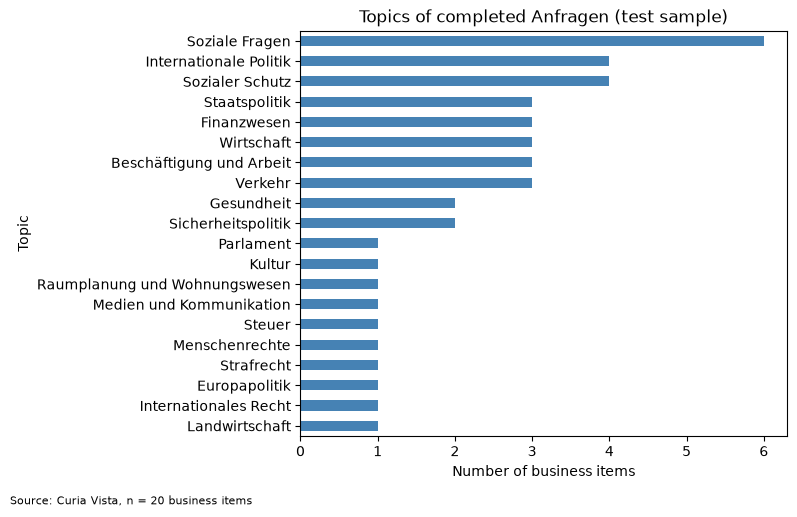

,business_items
topic,
Soziale Fragen,6
Internationale Politik,4
Sozialer Schutz,4
Staatspolitik,3
Finanzwesen,3
Wirtschaft,3
Beschäftigung und Arbeit,3
Verkehr,3
Gesundheit,2


In [2]:
topic_counts = topics["topic"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
topic_counts.plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("Number of business items")
ax.set_ylabel("Topic")
ax.set_title("Topics of completed Anfragen (test sample)")
ax.xaxis.get_major_locator().set_params(integer=True)
fig.text(0.01, -0.02, f"Source: Curia Vista, n = {len(df)} business items", fontsize=8)
plt.tight_layout()
plt.show()

topic_counts.sort_values(ascending=False).to_frame("business_items")

## RQ3: Party participation
Number of completed Anfragen per party of the submitter.

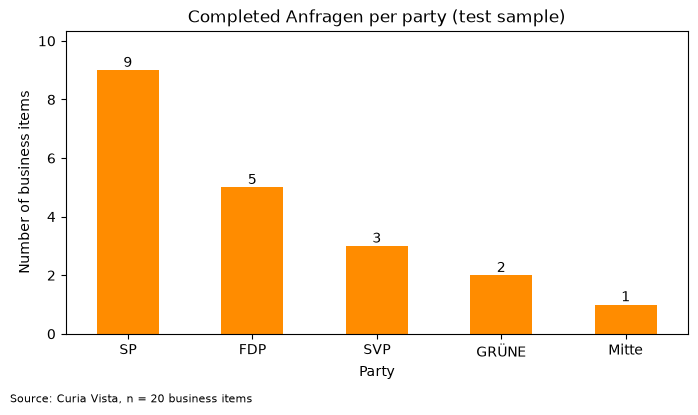

,business_items,share_%
party_short,,
SP,9,45.0
FDP,5,25.0
SVP,3,15.0
GRÜNE,2,10.0
Mitte,1,5.0


In [3]:
party_counts = df["party_short"].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
party_counts.plot.bar(ax=ax, color="darkorange")
ax.set_xlabel("Party")
ax.set_ylabel("Number of business items")
ax.set_title("Completed Anfragen per party (test sample)")
ax.tick_params(axis="x", rotation=0)
ax.yaxis.get_major_locator().set_params(integer=True)
ax.set_ylim(0, party_counts.max() * 1.15)
for i, value in enumerate(party_counts):
    ax.text(i, value, str(value), ha="center", va="bottom")
fig.text(0.01, -0.02, f"Source: Curia Vista, n = {len(df)} business items", fontsize=8)
plt.tight_layout()
plt.show()

pd.DataFrame({"business_items": party_counts,
              "share_%": (party_counts / party_counts.sum() * 100).round(1)})

## Topics × parties (heatmap)
Combines RQ1 and RQ3: which party submits questions on which topic. Second visualisation type.

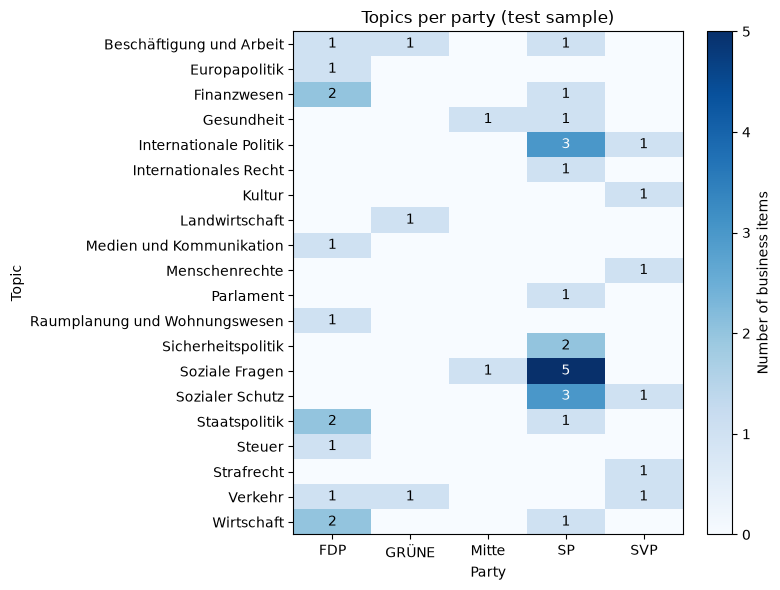

In [4]:
crosstab = pd.crosstab(topics["topic"], topics["party_short"])

fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(crosstab.values, cmap="Blues", aspect="auto")
ax.set_xticks(range(len(crosstab.columns)), crosstab.columns)
ax.set_yticks(range(len(crosstab.index)), crosstab.index)
ax.set_xlabel("Party")
ax.set_ylabel("Topic")
ax.set_title("Topics per party (test sample)")
for (row, col), value in pd.DataFrame(crosstab.values).stack().items():
    if value > 0:
        color = "white" if value > crosstab.values.max() / 2 else "black"
        ax.text(col, row, value, ha="center", va="center", color=color)
fig.colorbar(image, ax=ax, label="Number of business items")
plt.tight_layout()
plt.show()

## Placeholder for RQ2: Topics per council
The canton is not part of the Curia Vista data. Once the council members data is merged via `CouncillorId`, `submitted_in` can be replaced by `canton`.

In [5]:
pd.crosstab(topics["topic"], topics["submitted_in"], margins=True, margins_name="Total")

submitted_in,Nationalrat,Ständerat,Total
topic,,,
Beschäftigung und Arbeit,3,0,3
Europapolitik,1,0,1
Finanzwesen,3,0,3
Gesundheit,2,0,2
Internationale Politik,3,1,4
Internationales Recht,0,1,1
Kultur,1,0,1
Landwirtschaft,1,0,1
Medien und Kommunikation,1,0,1


## Limitations
- Test sample only (20 completed Anfragen from 2026) – no conclusions possible yet.
- Only business type "Anfrage"; RQ1–RQ3 require further business types.
- Canton missing → RQ2 cannot be answered yet.